
Automated search for the largest auditable margin that preserves a single winner set, a sweep for the smallest sample fraction that reliably passes the synthetic audit, and a batch runner over `data/scot-elex/6_cands` that writes results to `data/audit_results/6_cands.json`.


In [ ]:
import json
from pathlib import Path
from votekit.pref_profile import PreferenceProfile

from votekit.cvr_loaders import load_scottish
from old_src.edouard.MeekGraph import MeekGraph
from old_src.edouard.src.margin_audits import end_to_end_synthetic_audit_3seat

DEFAULT_PROFILE_PATH = "data/scot-elex/6_cands/south_lanarkshire_2012_ward4.csv"
profile, NUM_WINNERS, *_ = load_scottish(DEFAULT_PROFILE_PATH)
NUM_WINNERS = 3
NUM_WINNERS = int(NUM_WINNERS)
num_ballots = profile.total_ballot_wt
print(
    f"Loaded {DEFAULT_PROFILE_PATH} with {num_ballots} ballots, m={NUM_WINNERS}, {len(profile.candidates)} candidates."
)

#D2_profile = PreferenceProfile.from_pickle("data/portland/Portland_D2.pkl")
#profile = PreferenceProfile.from_pickle("data/portland/Portland_D4.pkl")
num_ballots = profile.total_ballot_wt

Loaded data/scot-elex/6_cands/south_lanarkshire_2012_ward4.csv with 4648.0 ballots, m=3, 6 candidates.


In [5]:

# Step 1: search for the largest auditable margin that keeps the same winners at every end node.

def build_graph_with_margin(profile, m, margin_value, use_numerical_labels=False):
    return MeekGraph(
        profile=profile,
        m=m,
        auditable_margins_per_deg=[margin_value] * m,
        use_numerical_labels=use_numerical_labels,
    )

def collect_end_winners(graph, m):
    end_nodes = [data for _, data in graph.tree.nodes(data=True) if len(data["winners"]) == m]
    return {tuple(sorted(node["winners"])) for node in end_nodes}


def search_for_max_margin(
    profile,
    m,
    start_fraction=1 / 200,
    max_fraction=0.35,
    growth=1.5,
    max_nodes=5000,
    max_edges=12000,
    max_steps=12,
    use_numerical_labels=False,
):
    margin = max(1, int(profile.total_ballot_wt * start_fraction))
    best = None
    successful = []

    tried_margins = set()

    for step in range(max_steps):
        margin_value = max(1, int(margin))
        if margin_value > profile.total_ballot_wt * max_fraction:
            break

        tried_margins.add(margin_value)
        print(f"Trying auditable margin {margin_value} (step {step + 1}/{max_steps})")
        graph = build_graph_with_margin(profile, m, margin_value, use_numerical_labels=use_numerical_labels)
        stats = graph.get_stats()
        end_winners = collect_end_winners(graph, m)

        #ripcord = stats["total_nodes"] > max_nodes or stats["total_edges"] > max_edges
        #if ripcord:
        #    print(
        #        f"Ripcord: graph reached {stats['total_nodes']} nodes/{stats['total_edges']} edges; stopping search."
        #    )
        #    break

        if len(end_winners) != 1:
            print(f"End nodes disagree on winners: {end_winners}; stopping search.")
            break

        best = (margin_value, graph, stats, end_winners)
        successful.append(best)
        margin = max(margin_value + 1, int(margin_value * growth))

    # Fallback: if nothing succeeded and margin 40 (or smaller) not tried, try 40.
    if best is None:
        fallback_margin = 40
        if fallback_margin not in tried_margins:
            print(f"Fallback: trying auditable margin {fallback_margin}")
            graph = build_graph_with_margin(profile, m, fallback_margin, use_numerical_labels=use_numerical_labels)
            stats = graph.get_stats()
            end_winners = collect_end_winners(graph, m)
            ripcord = stats["total_nodes"] > max_nodes or stats["total_edges"] > max_edges
            if not ripcord and len(end_winners) == 1:
                best = (fallback_margin, graph, stats, end_winners)
                successful.append(best)

    if best is None:
        raise RuntimeError("No auditable margin found before ripcord or winner disagreement.")
    return (*best, successful)


In [6]:

margin_params = {
    "start_fraction": 1 / 200,
    "max_fraction": 0.35,
    "growth": 1.5,
    "max_nodes": 5000,
    "max_edges": 12000,
}

best_margin, audit_graph, graph_stats, end_winners, margin_candidates = search_for_max_margin(profile, NUM_WINNERS, **margin_params)
print(f"Chosen auditable margin: {best_margin}")
print(f"Winner set at end nodes: {end_winners}")
print(f"Graph stats: {graph_stats}")

# Uncomment to visualize the resulting graph once the search settles on a margin.
#audit_graph.plot_graph(figsize=(8, 12), node_size=200, label_nodes=True, title="Audit Graph", label_edges=True, vertical_spacing=1000)


Trying auditable margin 23 (step 1/12)
Trying auditable margin 34 (step 2/12)
Trying auditable margin 51 (step 3/12)
Trying auditable margin 76 (step 4/12)
Trying auditable margin 114 (step 5/12)
Trying auditable margin 171 (step 6/12)
End nodes disagree on winners: {(np.int64(0), np.int64(1), np.int64(2)), (np.int64(0), np.int64(1), np.int64(5))}; stopping search.
Chosen auditable margin: 114
Winner set at end nodes: {(np.int64(0), np.int64(1), np.int64(5))}
Graph stats: {'total_nodes': 10, 'total_edges': 11, 'layers': 7, 'nodes_per_layer': {0: 1, 1: 1, 2: 2, 3: 2, 4: 1, 5: 2, 6: 1}}


/home/nardo/research/meek/src/edouard/MeekGraph.py:445: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


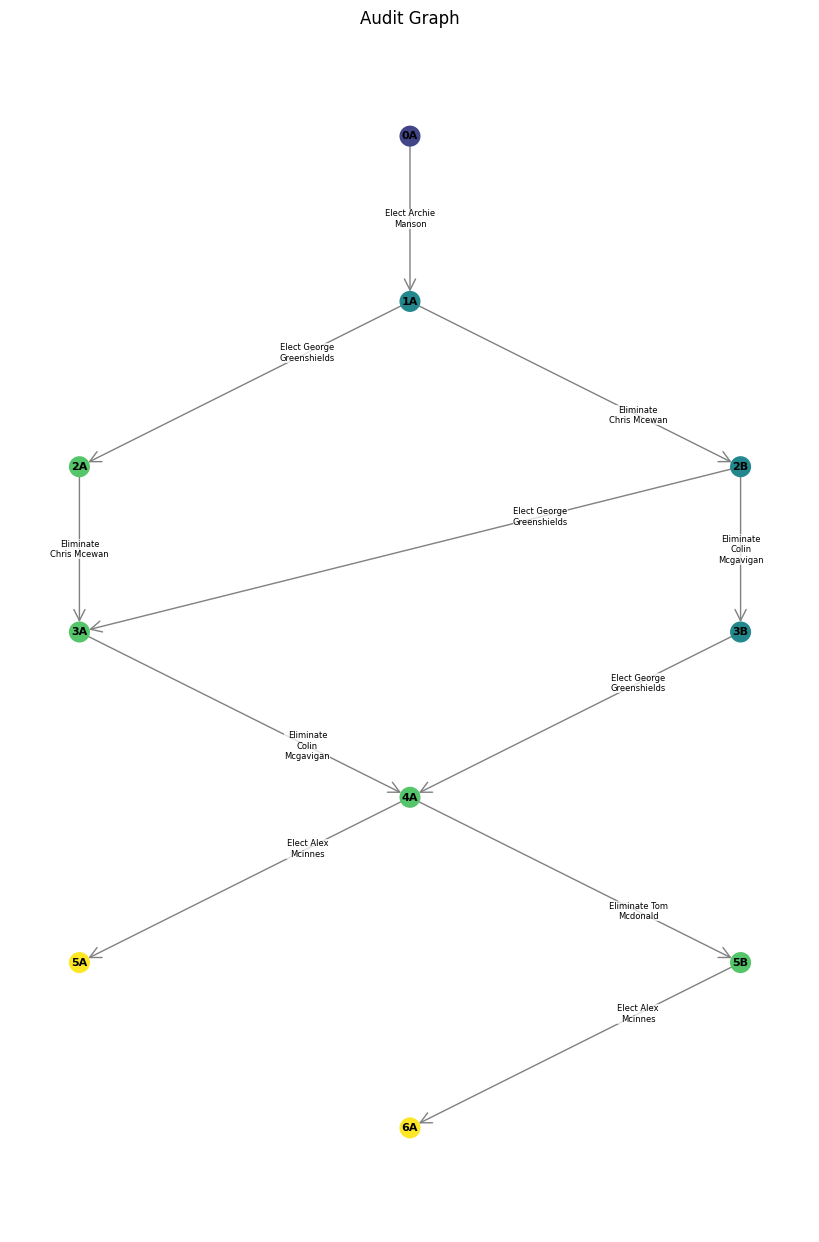

In [7]:
audit_graph.plot_graph(figsize=(8, 12), node_size=200, label_nodes=True, title="Audit Graph", label_edges=True, vertical_spacing=1000)

In [ ]:
from old_src.edouard.audit_machinery import alternative_K_upper
from old_src.edouard.utils import convert_pf_to_numpy_arrays
import numpy as np
import io
from contextlib import redirect_stdout, redirect_stderr, nullcontext
# Step 2: sweep sample_size_fraction downward until the audit stops passing consistently.

def run_audit_trials(
    profile,
    graph,
    sample_fraction,
    num_ghosts,
    hypergeo_var_bounds = [],
    alpha=0.05,
    noise_level=0.02,
    trials=10,
    verbose=False,
    suppress_output=True,
):
    successes = 0
    if len(hypergeo_var_bounds) != 21:
        ballot_matrix, mult_vec, _ = convert_pf_to_numpy_arrays(profile)
        num_original_ballots = np.sum(mult_vec)
        _N = int(num_original_ballots+num_ghosts)
        sample_size = int(_N * sample_fraction)
        hypergeo_var_bounds = [alternative_K_upper(_N, sample_size, i, alpha)/_N for i in range(21)]
    for attempt in range(trials):
        if verbose:
            print(f"Trial {attempt + 1}/{trials} at sample fraction {sample_fraction:.5f}")
        stdout_cm = redirect_stdout(io.StringIO()) if suppress_output else nullcontext()
        stderr_cm = redirect_stderr(io.StringIO()) if suppress_output else nullcontext()
        with stdout_cm, stderr_cm:
            result = end_to_end_synthetic_audit_3seat(
                profile,
                graph,
                num_ghosts=num_ghosts,
                sample_size_fraction=sample_fraction,
                alpha=alpha,
                noise_level=noise_level,
                hypergeo_var_bounds= hypergeo_var_bounds,
                verbose=verbose,
            )
        successes += bool(result)
    return successes

def find_min_sample_fraction(
    profile,
    graph,
    num_ghosts,
    candidate_fractions,
    alpha=0.05,
    noise_level=0.02,
    trials=10,
    success_cutoff=9,
    verbose=False,
):
    results = []
    best_fraction = None
    root_error = False
    if not candidate_fractions:
        return best_fraction, results, root_error

    # Start at 10% if present, else use the first entry
    start_idx = next((i for i, f in enumerate(candidate_fractions) if abs(f - 0.10) < 1e-9), 0)

    def audit_at_index(idx):
        fraction = candidate_fractions[idx]
        error_info = None
        nonlocal root_error
        try:
            successes = run_audit_trials(
                profile,
                graph,
                fraction,
                num_ghosts,
                alpha=alpha,
                noise_level=noise_level,
                trials=trials,
                verbose=verbose,
                suppress_output=not verbose,
            )
        except Exception as exc:
            print(f"Audit exception at fraction {fraction:.5f}: {exc}")
            successes = -1  # flag for exception
            if "No positive real roots for P1 or P2 at given parameters." in str(exc):
                root_error = True
                error_info = {
                    "message": str(exc),
                    "params": {
                        "fraction": fraction,
                        "num_ghosts": num_ghosts,
                        "alpha": alpha,
                        "noise_level": noise_level,
                        "trials": trials,
                    },
                }
        results.append(
            {
                "fraction": fraction,
                "successes": successes,
                "error": error_info,
            }
        )
        print(f"Fraction {fraction:.5f}: {successes}/{trials} runs passed.")
        return successes

    first_successes = audit_at_index(start_idx)
    if first_successes < 0:
        return best_fraction, results, root_error

    if first_successes >= success_cutoff:
        best_fraction = candidate_fractions[start_idx]
        # Try smaller fractions (indices after start_idx) until failure
        for i in range(start_idx + 1, len(candidate_fractions)):
            successes = audit_at_index(i)
            if successes < 0:
                break
            if successes >= success_cutoff:
                best_fraction = candidate_fractions[i]
                continue
            break
    else:
        # Need a larger fraction: walk toward the start of the list
        for i in range(start_idx - 1, -1, -1):
            successes = audit_at_index(i)
            if successes < 0:
                break
            if successes >= success_cutoff:
                best_fraction = candidate_fractions[i]
                break

    return best_fraction, results, root_error


In [10]:

NUM_GHOSTS = max(1, num_ballots // 100)
ALPHA = 0.05
NOISE_LEVEL = 0.02
TRIALS = 10
SUCCESS_CUTOFF = 9

candidate_sample_fractions = [
    1/2,
    1/3,
    1/5,
    15/100,
    1 / 10,
    1 / 15,
    1 / 20,
    1 / 25,
    1 / 30,
    1 / 40,
    1 / 50,
    1 / 60,
]

best_fraction, audit_results, root_error = find_min_sample_fraction(
    profile,
    audit_graph,
    NUM_GHOSTS,
    candidate_sample_fractions,
    alpha=ALPHA,
    noise_level=NOISE_LEVEL,
    trials=TRIALS,
    success_cutoff=SUCCESS_CUTOFF,
    verbose=True,
)

if best_fraction:
    print(f"Using sample fraction {best_fraction:.5f} (~{int(best_fraction * num_ballots)} ballots) with >= {SUCCESS_CUTOFF}/{TRIALS} successes.")
elif root_error:
    print("Audit hit root error; consider rerunning with a lower auditable margin.")
else:
    print(f"No candidate sample fraction met the success threshold; consider increasing the fraction or relaxing the cutoff.")


Trial 1/10 at sample fraction 0.10000
Number of ballots N: 4694
Sample size n: 469
-------------------------- Auditing node 0A with degree 0 ------------------
First round results at node 0A:
FPV scores: {0: np.float64(1149.0), 1: np.float64(1625.0), 2: np.float64(313.0), 3: np.float64(199.0), 4: np.float64(487.0), 5: np.float64(875.0)}
Quota: 1162.000001
Initial losers: []
Initial winners: []
Canonical loser: 3
Allowable winners: [1]
Allowable losers: []
Succesfully checked that candidate Archie Manson must have quota at node 0A, M_cq > 418.85086749941354 and M_cq = 462.9999989999999
Succesfully checked that canonical winner Archie Manson  does not lose to George Greenshields at node 0A, M_cl > 387.55938578616747 and M_cl = 476.0
Succesfully checked that canonical winner Archie Manson  does not lose to Tom Mcdonald at node 0A, M_cl > 1237.9058081076798 and M_cl = 1312.0
Succesfully checked that canonical winner Archie Manson  does not lose to Chris Mcewan at node 0A, M_cl > 1369.15095

In [ ]:

# Batch: iterate over one or more profile directories and record outcomes.
from tqdm import tqdm

import io
from contextlib import redirect_stdout, redirect_stderr, nullcontext

# Edit this list to audit multiple directories
BATCH_DIRS = [Path(f"data/scot-elex/{i}_cands") for i in [6,7,8,9,10]]
RESULT_DIR = Path("data/audit_results")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Suppress noisy output during batch audits to keep tqdm visible
BATCH_SUPPRESS_OUTPUT = True

if len(BATCH_DIRS) == 1 and BATCH_DIRS[0].name.endswith("_cands"):
    result_name = f"{BATCH_DIRS[0].name}.json"
else:
    result_name = "combined.json"
BATCH_RESULT_PATH = RESULT_DIR / result_name

# Resume if results already exist; otherwise start fresh.
if BATCH_RESULT_PATH.exists():
    existing_records = json.loads(BATCH_RESULT_PATH.read_text())
else:
    existing_records = []
existing_by_path = {rec.get("path"): rec for rec in existing_records}
results_map = existing_by_path.copy()  # path -> record

all_csv_paths = []
for d in BATCH_DIRS:
    if not d.exists():
        print(f"Warning: directory {d} not found; skipping.")
        continue
    all_csv_paths.extend(sorted(d.glob("*.csv")))

tqdm_iter = tqdm(all_csv_paths, desc="Auditing profiles", leave=True)

for csv_path in tqdm_iter:
    path_str = str(csv_path)
    if path_str in results_map and results_map[path_str].get("status") == "ok":
        # Already have a successful audit; skip.
        continue

    tqdm_iter.set_postfix_str(csv_path.name)
    profile_batch, seats, *_ = load_scottish(csv_path)
    orig_seats = int(seats)
    seats = 3  # audit as 3-seat regardless, but record original
    entry = {
        "profile": csv_path.name,
        "path": path_str,
        "m": orig_seats,
        "audited_as_m": seats,
        "total_ballot_wt": int(profile_batch.total_ballot_wt),
    }

    stdout_cm = redirect_stdout(io.StringIO()) if BATCH_SUPPRESS_OUTPUT else nullcontext()
    stderr_cm = redirect_stderr(io.StringIO()) if BATCH_SUPPRESS_OUTPUT else nullcontext()
    with stdout_cm, stderr_cm:
        try:
            best_margin_batch, audit_graph_batch, graph_stats_batch, end_winners_batch, margin_candidates = search_for_max_margin(
                profile_batch,
                seats,
                **margin_params,
            )
        except Exception as exc:
            entry["sample_fraction"] = 1.0
            entry["status"] = f"margin_search_failed: {exc}"
            results_map[path_str] = entry
            BATCH_RESULT_PATH.write_text(json.dumps(list(results_map.values()), indent=2))
            continue

        num_ghosts_batch = max(1, entry["total_ballot_wt"] // 100)

        # Try margins from highest to lowest when root error occurs
        best_fraction_batch = None
        audit_attempts_batch = []
        status_note = "no_fraction_met_cutoff"
        for margin_value, graph_candidate, stats_candidate, winners_candidate in reversed(margin_candidates):
            best_fraction_batch, audit_attempts_batch, root_error = find_min_sample_fraction(
                profile_batch,
                graph_candidate,
                num_ghosts_batch,
                candidate_sample_fractions,
                alpha=ALPHA,
                noise_level=NOISE_LEVEL,
                trials=TRIALS,
                success_cutoff=SUCCESS_CUTOFF,
                verbose=False,
            )
            entry["auditable_margin"] = margin_value
            if root_error and margin_candidates[0][0] != margin_value:
                # try lower margin
                continue
            status_note = "ok" if best_fraction_batch else ("root_error_exhausted" if root_error else "no_fraction_met_cutoff")
            break

    entry["status"] = status_note
    entry["sample_fraction"] = float(best_fraction_batch) if best_fraction_batch else 1.0
    entry["audit_results"] = [
        {
            "fraction": float(r.get("fraction")),
            "successes": int(r.get("successes", 0)),
            "error": r.get("error"),
        }
        for r in audit_attempts_batch
    ]
    results_map[path_str] = entry
    BATCH_RESULT_PATH.write_text(json.dumps(list(results_map.values()), indent=2))

# Append any prior non-ok entries that were not reprocessed (should already be in results_map)
BATCH_RESULT_PATH.write_text(json.dumps(list(results_map.values()), indent=2))
print(f"Wrote {len(results_map)} entries to {BATCH_RESULT_PATH}")


Auditing profiles: 100%|██████████| 8/8 [03:17<00:00, 24.73s/it, north_lanarkshire_2017_ward19.csv]

Wrote 8 entries to data/audit_results/12_cands.json


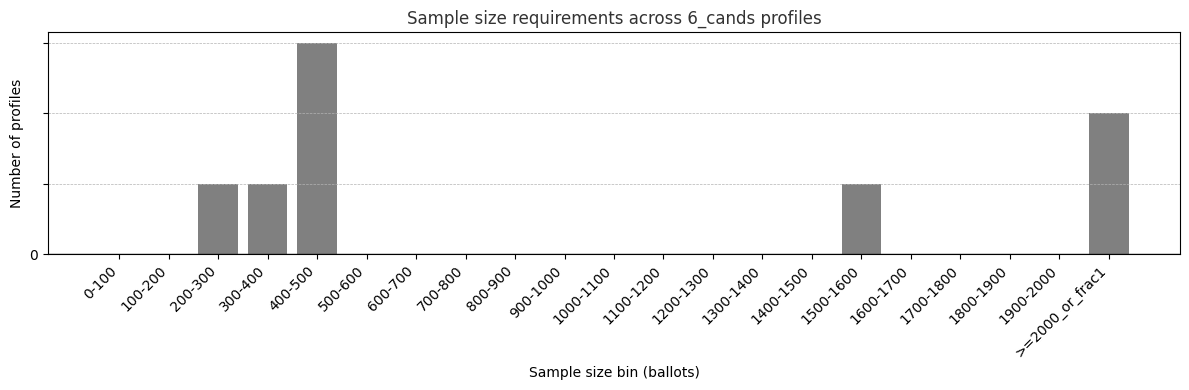

In [13]:

# Plot distribution of sample sizes (ballots) across audited profiles
import json
from pathlib import Path
import matplotlib.pyplot as plt

result_path = Path("data/audit_results/12_cands.json")
if not result_path.exists():
    raise FileNotFoundError("Run the batch cell first to generate results.")

records = json.loads(result_path.read_text())

# Define bins: 0-100, 100-200, ..., 1900-2000, and ">=2000 or fraction=1"
bin_edges = list(range(0, 2001, 100))
bin_labels = [f"{bin_edges[i]}-{bin_edges[i+1]}" for i in range(len(bin_edges)-1)]
extra_label = ">=2000_or_frac1"
counts = {label: 0 for label in bin_labels}
counts[extra_label] = 0

for rec in records:
    frac = float(rec.get("sample_fraction", 1.0))
    total_wt = int(rec.get("total_ballot_wt", 0))
    sample_size = total_wt * frac
    if abs(frac - 1.0) < 1e-9:
        counts[extra_label] += 1
        continue
    placed = False
    for i in range(len(bin_edges)-1):
        if bin_edges[i] <= sample_size < bin_edges[i+1]:
            counts[bin_labels[i]] += 1
            placed = True
            break
    if not placed:
        counts[extra_label] += 1

vals = list(counts.values())
max_count = max(vals) if vals else 0

plt.figure(figsize=(12, 4))
plt.bar(list(counts.keys()), vals, color="0.5")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of profiles")
plt.xlabel("Sample size bin (ballots)")
plt.title("Sample size requirements across 6_cands profiles", color="0.2")
plt.grid(axis="y", linestyle="--", linewidth=0.5, color="0.7")
ax = plt.gca()
y_ticks = list(range(0, max_count + 1))
ax.set_yticks(y_ticks)
ax.set_yticklabels([str(t) if t % 5 == 0 else "" for t in y_ticks])
for t in y_ticks:
    if t % 5 == 0:
        ax.axhline(t, color="0.2", linewidth=1)
plt.tight_layout()
plt.show()


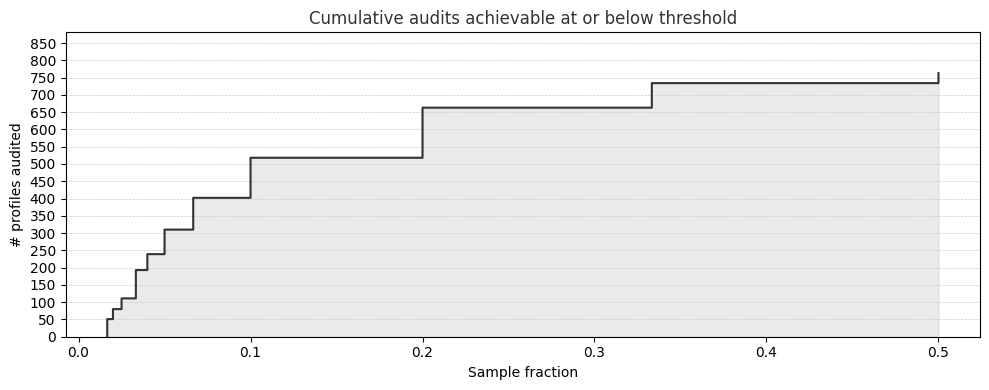

734/881 profiles (83.3%) require fraction <= 0.4.


In [11]:

# Cumulative audit capacity plot across one or more result JSON files
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Configure which result files to include
result_paths = [
    Path("data/audit_results/combined.json"),
]

# Choose plotting mode: "fraction" (relative) or "sample_size" (absolute ballots)
mode = "fraction"  # or "fraction"
# Thresholds used for summary printouts
fraction_threshold = 0.4
sample_size_threshold = 1000

records = []
for rp in result_paths:
    if rp.exists():
        records.extend(json.loads(rp.read_text()))
    else:
        print(f"Warning: {rp} not found, skipping.")

total_profiles = len(records)

# Use only profiles that audited successfully
vals = []
for rec in records:
    if rec.get("status") != "ok":
        continue
    frac = float(rec.get("sample_fraction", 1.0))
    total_wt = float(rec.get("total_ballot_wt", 0))
    if mode == "sample_size":
        vals.append(frac * total_wt)
    else:
        vals.append(frac)

vals = sorted(vals)
if not vals:
    raise ValueError("No successful audits found in the provided result files.")

x_vals = vals
y_vals = list(range(1, len(vals) + 1))

plt.figure(figsize=(10, 4))
plt.step(x_vals, y_vals, where="post", color="0.2")
plt.fill_between(x_vals, y_vals, step="post", color="0.8", alpha=0.4)
plt.ylabel("# profiles audited")
if mode == "sample_size":
    plt.xlabel("Sample size (ballots)")
else:
    plt.xlabel("Sample fraction")
plt.title("Cumulative audits achievable at or below threshold", color="0.2")
plt.grid(axis="y", linestyle="--", linewidth=0.5, color="0.8")
ax = plt.gca()
ax.set_ylim(0, total_profiles)
y_ticks = list(range(0, total_profiles + 1,50))
ax.set_yticks(y_ticks)
ax.set_yticklabels([str(t) if t % 50 == 0 else "" for t in y_ticks])
#for t in y_ticks:
#    if t % 20 == 0:
#        ax.axhline(t, color="0.2", linewidth=1)
plt.tight_layout()
plt.show()

if mode == "sample_size":
    threshold_val = sample_size_threshold
else:
    threshold_val = fraction_threshold
num_at_or_below = sum(1 for v in vals if v <= threshold_val)
proportion = num_at_or_below / total_profiles if total_profiles else 0
print(f"{num_at_or_below}/{total_profiles} profiles ({proportion:.1%}) require {mode} <= {threshold_val}.")


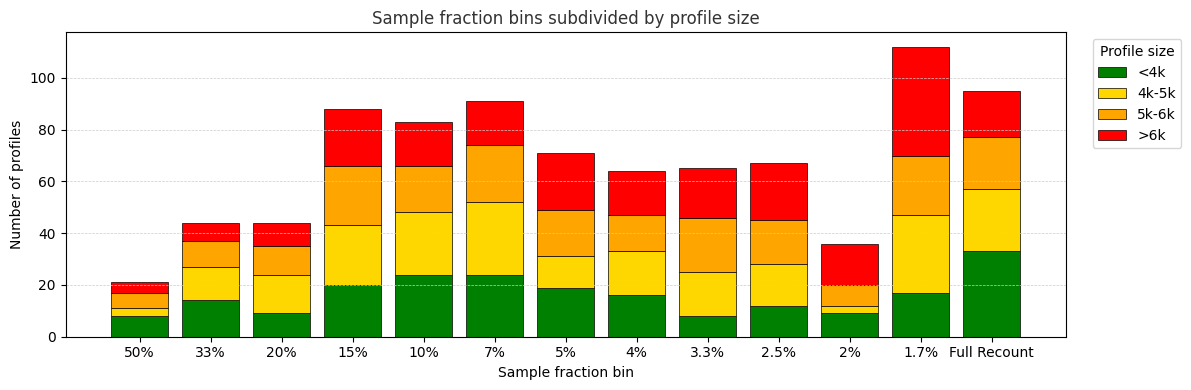

In [12]:

# Color-coded stacked bar plot: sample fraction bins subdivided by total ballot weight
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Result files to include (e.g., combined.json or specific folders)
result_paths = [
    Path("data/audit_results/combined.json"),
]

# Fraction bins aligned to candidate_sample_fractions
bin_specs = [
    (1/2, "50%"),
    (1/3, "33%"),
    (1/5, "20%"),
    (15/100, "15%"),
    (1/10, "10%"),
    (1/15, "7%"),
    (1/20, "5%"),
    (1/25, "4%"),
    (1/30, "3.3%"),
    (1/40, "2.5%"),
    (1/50, "2%"),
    (1/60, "1.7%"),
    (1.0, "Full Recount"),
]

# Ballot-weight bins and colors
size_bins = [
    (0, 4000, "green", "<4k"),
    (4000, 5000, "gold", "4k-5k"),
    (5000, 6000, "orange", "5k-6k"),
    (6000, float("inf"), "red", ">6k"),
]

records = []
for rp in result_paths:
    if rp.exists():
        records.extend(json.loads(rp.read_text()))

# Aggregate counts by fraction bin and size bin (only successful audits)
bin_values = [b[0] for b in bin_specs]
bin_labels = [b[1] for b in bin_specs]
counts = {label: {sb[3]: 0 for sb in size_bins} for label in bin_labels}

for rec in records:
    #if rec.get("status") != "ok":
    #    continue
    frac = float(rec.get("sample_fraction", 1.0))
    total_wt = float(rec.get("total_ballot_wt", 0))

    # assign fraction bin (nearest bin)
    assigned_label = None
    closest_idx = min(range(len(bin_values)), key=lambda i: abs(frac - bin_values[i]))
    assigned_label = bin_labels[closest_idx]

    # assign size bin
    size_label = None
    for low, high, color, label in size_bins:
        if low <= total_wt < high:
            size_label = label
            break
    if size_label is None:
        size_label = size_bins[-1][3]

    counts[assigned_label][size_label] += 1

# Build stacked bar plot
plt.figure(figsize=(12, 4))
bottom = [0] * len(bin_labels)
for low, high, color, label in size_bins:
    heights = [counts[b][label] for b in bin_labels]
    plt.bar(bin_labels, heights, bottom=bottom, color=color, label=label, edgecolor="black", linewidth=0.5)
    bottom = [b + h for b, h in zip(bottom, heights)]

plt.ylabel("Number of profiles")
plt.xlabel("Sample fraction bin")
plt.title("Sample fraction bins subdivided by profile size", color="0.2")
plt.grid(axis="y", linestyle="--", linewidth=0.5, color="0.8")
plt.legend(title="Profile size", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


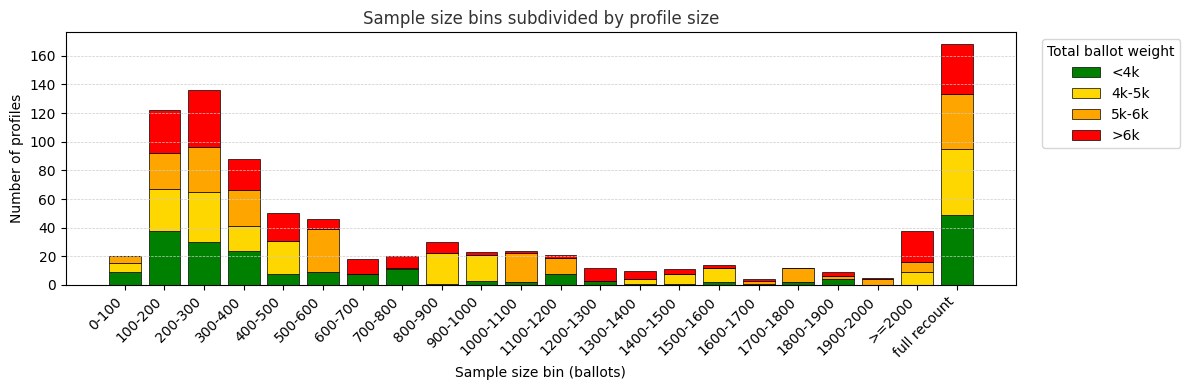

In [36]:

# Color-coded stacked bar plot: absolute sample size bins subdivided by total ballot weight
import json
from pathlib import Path
import matplotlib.pyplot as plt

result_paths = [
    Path("data/audit_results/combined.json"),
]

# Sample size bins (ballots)
sample_edges = list(range(0, 2001, 100))
sample_labels = [f"{sample_edges[i]}-{sample_edges[i+1]}" for i in range(len(sample_edges)-1)]
extra_sample_label = ">=2000"

# Ballot-weight bins and colors (profile sizes)
size_bins = [
    (0, 4000, "green", "<4k"),
    (4000, 5000, "gold", "4k-5k"),
    (5000, 6000, "orange", "5k-6k"),
    (6000, float("inf"), "red", ">6k"),
]

records = []
for rp in result_paths:
    if rp.exists():
        records.extend(json.loads(rp.read_text()))

counts = {label: {sb[3]: 0 for sb in size_bins} for label in sample_labels + [extra_sample_label]+["full recount"]}

for rec in records:
    #if rec.get("status") != "ok":
    #    continue
    frac = float(rec.get("sample_fraction", 1.0))
    total_wt = float(rec.get("total_ballot_wt", 0))
    sample_size = frac * total_wt

    # sample size bin
    sample_label = extra_sample_label
    if frac == 1.0:
        sample_label = "full recount"
    for i in range(len(sample_edges)-1):
        if sample_edges[i] <= sample_size < sample_edges[i+1]:
            sample_label = sample_labels[i]
            break

    # profile size bin
    size_label = size_bins[-1][3]
    for low, high, color, label in size_bins:
        if low <= total_wt < high:
            size_label = label
            break

    counts[sample_label][size_label] += 1

# Build stacked bar plot
plt.figure(figsize=(12, 4))
bottom = [0] * len(counts)
x_labels = list(counts.keys())
for low, high, color, label in size_bins:
    heights = [counts[x][label] for x in x_labels]
    plt.bar(x_labels, heights, bottom=bottom, color=color, label=label, edgecolor="black", linewidth=0.5)
    bottom = [b + h for b, h in zip(bottom, heights)]

plt.ylabel("Number of profiles")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Sample size bin (ballots)")
plt.title("Sample size bins subdivided by profile size", color="0.2")
plt.grid(axis="y", linestyle="--", linewidth=0.5, color="0.8")
plt.legend(title="Total ballot weight", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
